# **USANDO LSTM E BEAM SEARCH PARA AUTOMPLETAR TEXTOS**

## **REALIZANDO O ENCODING DO TEXTO**

Para trabalharmos com texto como entrada da *RNN*, primeiro é necessário codificá-lo da maneira adequada. Para isso, utilizamos a técnica **one-hot encoding**, a mesma usada para as categorias nos problemas de classificação de imagem. Usaremos essa técnica pois nesse primeiro momento trabalharemos com o texto como uma sequência de caracteres, não como uma sequência de palavras. Logo, o *one-hot encoding* funciona bem para caracteres, haja vista que temos somente algumas dezendas de caracteres. Pensando nesse caminho, o *one-hot encoding* de palavras é menos eficiente, pois resultaria em vetores muito mais largos, porque a largura do vetor de entrada é a mesma que o número total de símbolos a serem codificados, e uma língua típica contém dezenas ou centenas de milhares de palavras.

Para tornar mais concreto e simples, suponha que o texto consista apenas em caracteres minúsculos e sem símbolos especiais (,.!@). A partir disso, podemos codificar um caractere como um vetor *one-hot* de largura 26, porque existem 26 caracteres minúsculos (trabalhando com a língua inglesa). Com isso, podemos definir uma *RNN* que recebe um vetor de 26 elementos como a etrada **x** e termina com uma camada *softmax* conectada a 26 saída (cada caractere minúsculo do alfabeto).

Agora podemos apresentar uma sequência de texto à rede, alimentando-a com um único caractere codificado em one-hot para cada passo de tempo, e a saída *softmax* pode ser interpretada como o que a rede prevê como sendo o próximo caractere. A saída de maior valor representa o caractere que a rede considera mais provável de ser o próximo. A saída com o segundo maior valor corresponde ao segundo caractere mais provável, e assim por diante.

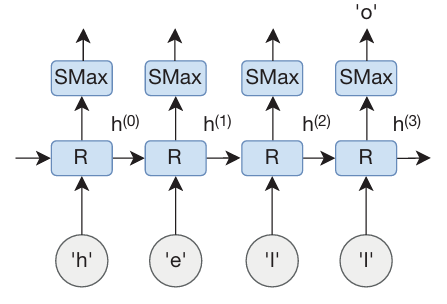 *RNN projetada acima em "funcionamento"*

A omagem acima ilustra a rede recorrente que pensamos para o caso. A cada passo de tempo um caractere é apresentado como *input* para a rede e no último passo de tempo ela prevê como próxima letra a letra **"o"**. Obviamente, a rede preverá algo durante os primeiros passos de tempo também, mas ignoramos as saídas durante esses passos porque sabemos que ainda não apresentamos a sequência de entrada inteira.

## **PREVENDO MÚLTIPLOS VALORES**

Nos materiais anteriores, o foco era prever sempre o próximo valor em uma sequência temporal, porém, muitas vezes, é bom ser capaz de prever sequências de saída mais logas do que apenas um único valor.

A maneira mais simples é criar múltiplos modelos, onde cada modelo adicional prevê um passo de tempo mais adiante. Para ilustrar isso, lembre do modelo de previsão de vendas de livros do material sobre *RNN*. Apresentamos ao modelo os dados de *input* e o valor de saída desejado *Y(t+1)*. Se tivéssemos usado os mesmos dados de entrada, mas em vez disso os apresentássemos com o valor de saída desejado para um passo de tempo posterior *Y(t+2)*, teríamos o modelo que prevê dois passos no futuro. Poderíamos então criar ainda outro modelo que treinamos com *Y(t+3)*, e assim por diante.  Essa abordagem é simples de implementar, mas não tão flexível, e também não há compartilhamento ou reutilização entre os modelos.

Outra opção é criar um modelo que prevê *m* passos de tempo de uma vez só. O modelo seria definido para ter *m* saída. Cada exemplo de treinamento consistiria nos dados de *input* e a saída desejada agora é uma sequência de *m* elementos. Com essa abordagem, obtemos o benefício potencial de reutilizar parâmetros para prever múltiplos passos de tempo, mas precisamos decidir antecipadamente quantos passos no futuro queremos prever, e se quisermos prever sequências extremamente longas, acabamos com um grande número de neurônios de saída.

Com essas duas abordagens, precisamos decidir antecipadamente, no momento do treinamento, quantos passos de tempo queremos prever. No entanto, assim como queremos ser capazes de processar sequências de entrada de comprimento variáveis, gostaríamos de escolher dinamicamente o comprimento da sequência de saída.

Uma maneira inteligente de fazer isso para o caso que o modelo prevê um valor futuro de uma variável com base apenas nos valores históricos dela mesma é pegar o valor de saída previsto para um passo de tempo e jogá-lo como entrada para o modelo no próximo passo de tempo. Quando um modelo de *Deep Learning* usa saída de um passo de tmepo como entrada para o próximo passo, ele é chamado de **modelo autorregressivo**.

Pensando no exemplo de autocompletar texto, uma boa ideia é alimentá-la, primeiramente, com o início da frase que queremos autocompletar, a partir disso ela irá prever um caractere. Esse caractere previsto será usada para realimentar a rede como entrada de maneira autorregressiva.

No entanto, não estamos pegando a saída exatamente como ela está, pois ela é uma distribuição de probabilidade, ou seja, um valor entre 0 e 1, e espera-se que a entrada seja codificada em *one-hot*, ou seja, apenas o elemento correspondente ao caractere previsto definido como número 1, o resto deverá ser 0. Assim, identificamos qual caractere a rede prevê com a maior probabilidade e realimentamos a codificação one-hot para esse caractere como entrada (autorregressão).